In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Please upload your 2-column .txt file:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

print(f"\nSuccessfully uploaded file: {filename}")

Please upload your 2-column .txt file:


Saving trainingdata.txt to trainingdata.txt

Successfully uploaded file: trainingdata.txt


In [3]:
data_separator = '\s+'
try:
    data = pd.read_csv(filename, sep=data_separator, header=None, names=['X', 'y'])
    print("Data loaded successfully. Here's the first 5 rows:")
    print(data.head())
except Exception as e:
    print(f"Error loading data: {e}")
    print("Please check your 'data_separator' variable (e.g., '\s+' or ',')")

X = data[['X']]

y = data['y']

Data loaded successfully. Here's the first 5 rows:
        X     y
0  0.4037  93.1
1  0.4032  92.9
2  0.4023  92.8
3  0.4016  92.8
4  0.4005  92.4


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-3922734925.py:1: SyntaxWarning: invalid escape sequence '\s'
  data_separator = '\s+'
/tmp/ipython-input-3922734925.py:8: SyntaxWarning: invalid escape sequence '\s'
  print("Please check your 'data_separator' variable (e.g., '\s+' or ',')")


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=41)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Total samples: 946
Training samples: 567
Testing samples: 379


In [5]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [6]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = rf_model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:f}")
print(f"R-squared (R2): {r2:f}")


--- Model Evaluation ---
Mean Squared Error (MSE): 0.304033
R-squared (R2): 0.998547


/tmp/ipython-input-4174361088.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.01)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


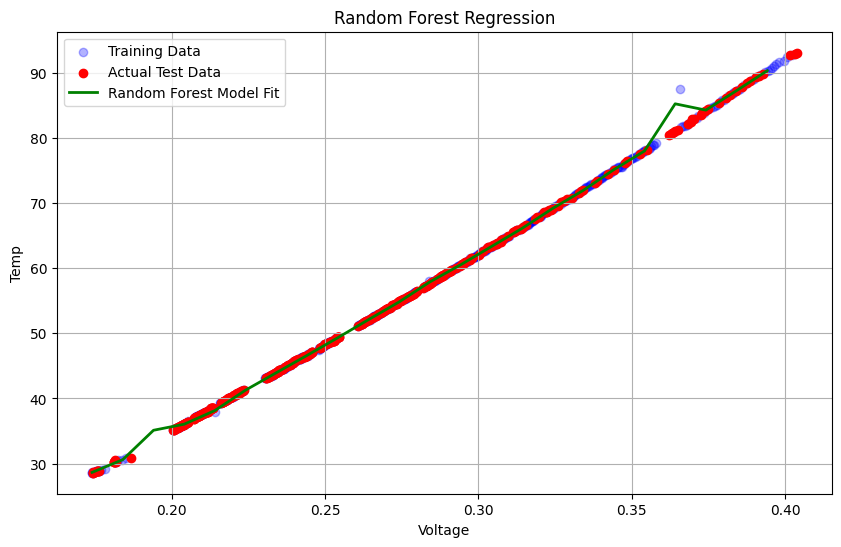

In [7]:
X_grid = np.arange(min(X.values), max(X.values), 0.01)
X_grid = X_grid.reshape(-1, 1)

y_grid_pred = rf_model.predict(X_grid)

plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train, color='blue', alpha=0.3, label='Training Data')

plt.scatter(X_test, y_test, color='red', label='Actual Test Data')

plt.plot(X_grid, y_grid_pred, color='green', linewidth=2, label='Random Forest Model Fit')

plt.title('Random Forest Regression')
plt.xlabel('Voltage')
plt.ylabel('Temp')
plt.legend()
plt.grid(True)
plt.show()

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=60, max_depth = 10, max_leaf_nodes=11)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [19]:
# print subset of predictions on test data
print(np.column_stack((X_test, y_test, y_pred))[:10])

[[ 0.2634     51.9        53.34557255]
 [ 0.3127     65.9        67.62482956]
 [ 0.2083     37.2        37.05626149]
 [ 0.4037     93.1        89.05046494]
 [ 0.2092     37.5        37.05626149]
 [ 0.2978     61.6        61.89006821]
 [ 0.2028     35.8        36.7501395 ]
 [ 0.2666     52.7        53.34557255]
 [ 0.3185     67.5        68.79540409]
 [ 0.285      57.9        58.64972053]]


In [9]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = rf_model.predict(X_test)


mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Squared Error (MSE): {mse:f}")
print(f"R-squared (R2): {r2:f}")


--- Model Evaluation ---
Mean Squared Error (MSE): 1.161318
R-squared (R2): 0.994451


/tmp/ipython-input-1914204885.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X.values), max(X.values), 0.01)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


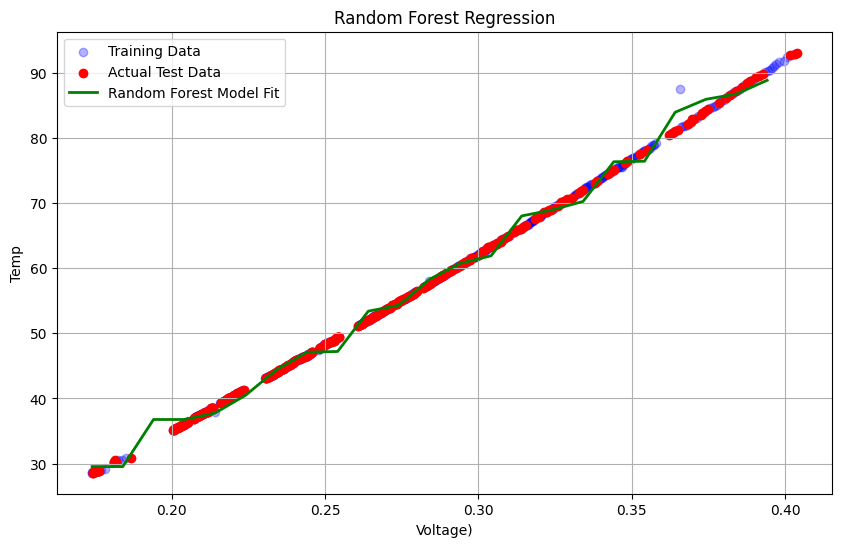

In [ ]:
X_grid = np.arange(min(X.values), max(X.values), 0.01)
X_grid = X_grid.reshape(-1, 1)

y_grid_pred = rf_model.predict(X_grid)

plt.figure(figsize=(10, 6))

plt.scatter(X_train, y_train, color='blue', alpha=0.3, label='Training Data')

plt.scatter(X_test, y_test, color='red', label='Actual Test Data')

plt.plot(X_grid, y_grid_pred, color='green', linewidth=2, label='Random Forest Model Fit')

plt.title('Random Forest Regression')
plt.xlabel('Voltage)')
plt.ylabel('Temp')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

print("--- C++ Data Dump for Random Forest ---")

cpp_trees_data = []

for i, tree in enumerate(rf_model.estimators_):
    tree_data = []
    tree_ = tree.tree_

    children_left = tree_.children_left
    children_right = tree_.children_right
    feature = tree_.feature
    threshold = tree_.threshold
    value = tree_.value

    def traverse_and_dump(node_id):
        if children_left[node_id] == children_right[node_id]:
            prediction_value = value[node_id][0][0]
            tree_data.append([node_id, -1, -1.0, prediction_value])
        else:
            tree_data.append([node_id, feature[node_id], threshold[node_id], -1.0])
            traverse_and_dump(children_left[node_id])
            traverse_and_dump(children_right[node_id])

    traverse_and_dump(0)
    cpp_trees_data.append(tree_data)

print(f"Total trees to dump: {len(cpp_trees_data)}")

print("\nFirst Tree Structure (Simplified for viewing):")
print("[Node Index, Feature Index (0), Threshold, Leaf Value (-1.0 if not leaf)]")
print(cpp_trees_data[0][:10])

--- C++ Data Dump for Random Forest ---
Total trees to dump: 60

First Tree Structure (Simplified for viewing):
[Node Index, Feature Index (0), Threshold, Leaf Value (-1.0 if not leaf)]
[[0, np.int64(0), np.float64(0.28790000081062317), -1.0], [np.int64(1), np.int64(0), np.float64(0.2397499978542328), -1.0], [np.int64(3), np.int64(0), np.float64(0.2152000069618225), -1.0], [np.int64(9), np.int64(0), np.float64(0.19280000030994415), -1.0], [np.int64(15), -1, -1.0, np.float64(29.742105263157896)], [np.int64(16), -1, -1.0, np.float64(36.824657534246576)], [np.int64(10), np.int64(0), np.float64(0.22664999961853027), -1.0], [np.int64(19), -1, -1.0, np.float64(40.32790697674418)], [np.int64(20), -1, -1.0, np.float64(44.012307692307694)], [np.int64(4), np.int64(0), np.float64(0.25780001282691956), -1.0]]


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

def get_tree_cpp_data(tree_estimator: DecisionTreeRegressor, tree_index: int) -> str:
    """
    Extracts the tree structure and formats it as a C++ PROGMEM array
    using 4-byte (single-precision) floats.
    """
    tree_ = tree_estimator.tree_

    children_left = tree_.children_left
    children_right = tree_.children_right
    threshold = tree_.threshold
    value = tree_.value
    node_data_list = []

    for node_id in range(tree_.node_count):
        left_child = children_left[node_id]
        right_child = children_right[node_id]


        if left_child == right_child:
            prediction_value = np.float32(value[node_id][0][0])


            node_str = f"{{-1, -1, {np.float32(-1.0):.6f}f, {prediction_value:.6f}f}}"

        else:

            split_threshold = np.float32(threshold[node_id])

            node_str = f"{{{left_child}, {right_child}, {split_threshold:.6f}f, {np.float32(-1.0):.6f}f}}"

        node_data_list.append(node_str)
    tree_cpp = f"""
// --- TREE {tree_index} (Size: {tree_.node_count} nodes) ---
const int TREE_{tree_index}_SIZE = {tree_.node_count};

// Array structure: {{left_idx, right_idx, threshold (float), prediction (float)}}
// Indices are PROGMEM array indices, NOT scikit-learn node IDs.
const float TREE_{tree_index}_DATA[][4] PROGMEM = {{
{',\n'.join(node_data_list)}
}};
"""
    return tree_cpp



cpp_output = []
tree_pointers_declaration = []
tree_size_declaration = []

print("=" * 60)
print("--- COPY AND PASTE THIS OUTPUT INTO YOUR ARDUINO SKETCH (.ino) ---")
print("=" * 60)
print("#include <avr/pgmspace.h>")
print()
print("// 1. DECLARE ALL TREE ARRAYS (DATA STORED IN FLASH)")

for i, estimator in enumerate(rf_model.estimators_):
    cpp_code = get_tree_cpp_data(estimator, i)
    cpp_output.append(cpp_code)

    tree_pointers_declaration.append(f"    (const float (*)[4])TREE_{i}_DATA")
    tree_size_declaration.append(f"    TREE_{i}_SIZE")

print("\n".join(cpp_output))

print("\n// 2. CREATE MASTER POINTERS AND SIZES FOR THE RANDOM FOREST")
print(f"#define NUM_TREES {len(rf_model.estimators_)}")

print("\nconst float (* const ALL_TREES_DATA[NUM_TREES])[4] PROGMEM = {")
print(",\n".join(tree_pointers_declaration))
print("};")

print("\nconst int ALL_TREES_SIZE[NUM_TREES] PROGMEM = {")
print(",\n".join(tree_size_declaration))
print("};")

print("\n" * 2)
print("=" * 60)
print("--- END OF C++ DATA ---")
print("=" * 60)

In [22]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Create the feature matrix for the quadratic fit: [X^2, X]
# The target variable is y_train
X_train_quadratic_features = pd.DataFrame({
    'X^2': X_train['X'].values ** 2,
    'X': X_train['X'].values
})

# 2. Fit the Regular Linear Least Squares Model (Quadratic)
regular_lsq_model = LinearRegression()
# X_train_quadratic_features is the independent variable matrix
# y_train is the dependent variable (target)
regular_lsq_model.fit(X_train_quadratic_features[['X^2', 'X']], y_train.values)


print("### Linear Least Squares (Quadratic) Results ###")

coeff_a = regular_lsq_model.coef_[0]
coeff_b = regular_lsq_model.coef_[1]
coeff_c = regular_lsq_model.intercept_

print(f"Fit Equation: Y = {coeff_a:.9f}*X^2 + {coeff_b:.9f}*X + {coeff_c:.9f}")

# 3. Predict Y for the Test set
X_test_quadratic_features = pd.DataFrame({
    'X^2': X_test['X'].values ** 2,
    'X': X_test['X'].values
})

# Prediction is direct using the linear model predict function
y_pred_regular_lsq = regular_lsq_model.predict(X_test_quadratic_features[['X^2', 'X']])

# print subset of predictions on test data
print(np.column_stack((X_test, y_test, y_pred_regular_lsq))[:10])

### Linear Least Squares (Quadratic) Results ###
Fit Equation: Y = 147.376208110*X^2 + 197.568472526*X + -10.357430491
[[ 0.2634     51.9        51.90700165]
 [ 0.3127     65.9        65.83286661]
 [ 0.2083     37.2        37.19057242]
 [ 0.4037     93.1        93.41940632]
 [ 0.2092     37.5        37.42376065]
 [ 0.2978     61.6        61.54849606]
 [ 0.2028     35.8        35.77072084]
 [ 0.2666     52.7        52.78917081]
 [ 0.3185     67.5        67.51830216]
 [ 0.285      57.9        57.92021668]]



Mean Squared Error (MSE) of Final Y Prediction: 0.009198
R-squared (R2) of Final Y Prediction: 0.999956


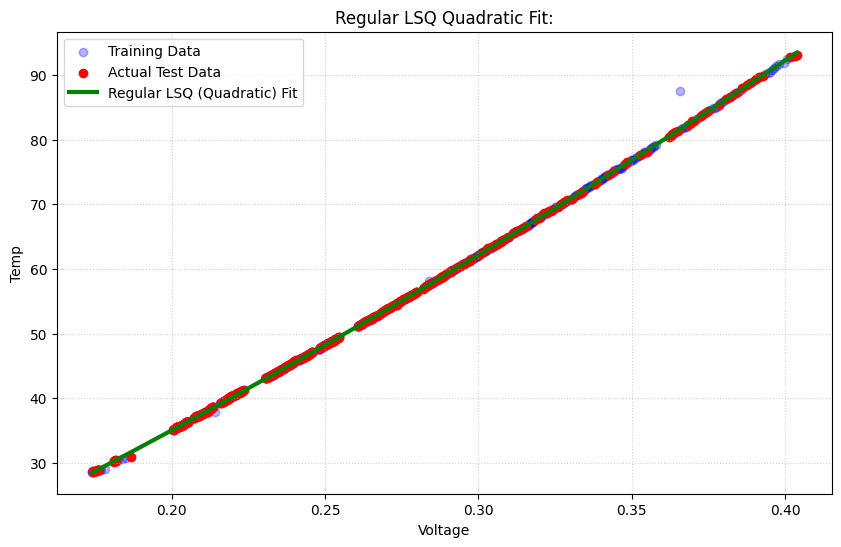

In [23]:
# 4. Evaluate the Model
mse_regular_lsq = mean_squared_error(y_test, y_pred_regular_lsq)
r2_regular_lsq = r2_score(y_test, y_pred_regular_lsq)

print(f"\nMean Squared Error (MSE) of Final Y Prediction: {mse_regular_lsq:f}")
print(f"R-squared (R2) of Final Y Prediction: {r2_regular_lsq:f}")


# 5. Plot the Results
plt.figure(figsize=(10, 6))

# Generate smooth X values for plotting the fit line
X_plot = np.linspace(X['X'].min(), X['X'].max(), 500)

# Calculate predicted Y values for the smooth X_plot
y_plot_regular = coeff_a * X_plot**2 + coeff_b * X_plot + coeff_c

# Scatter plots for data
plt.scatter(X_train['X'], y_train, color='blue', alpha=0.3, label='Training Data')
plt.scatter(X_test['X'], y_test, color='red', label='Actual Test Data')

# Plot the fitted curve
plt.plot(X_plot, y_plot_regular, color='green', linewidth=3, label='Regular LSQ (Quadratic) Fit')

plt.title('Regular LSQ Quadratic Fit:')
plt.xlabel('Voltage')
plt.ylabel('Temp')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [27]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

Y_train_inverse_features = pd.DataFrame({
    'Y': y_train.values,
    'Y^2': y_train.values ** 2
})

X_train_target = X_train['X'].values

inverse_lsq_model = LinearRegression()
inverse_lsq_model.fit(Y_train_inverse_features[['Y^2', 'Y']], X_train_target)


print("### Inverse Linear Least Squares (Quadratic) Results ###")

coeff_a = inverse_lsq_model.coef_[0]
coeff_b = inverse_lsq_model.coef_[1]
coeff_c = inverse_lsq_model.intercept_

print(f"Inverse Fit Equation: X = {coeff_a:.9f}*Y^2 + {coeff_b:.9f}*Y + {coeff_c:.9f}")

def inverse_quadratic_predict(X_vals, a, b, c):
    discriminant = b**2 - 4 * a * (c - X_vals)
    Y_pred_plus = (-b + np.sqrt(discriminant)) / (2 * a)
    return np.where(discriminant >= 0, Y_pred_plus, np.nan)


X_test_target = X_test['X'].values
y_pred_inverse_lsq = inverse_quadratic_predict(X_test_target, coeff_a, coeff_b, coeff_c)


valid_indices = ~np.isnan(y_pred_inverse_lsq)
y_test_valid = y_test[valid_indices]
y_pred_valid = y_pred_inverse_lsq[valid_indices]

# print subset of predictions on test data
print(np.column_stack((X_test, y_test, y_pred_valid))[:10])

### Inverse Linear Least Squares (Quadratic) Results ###
Inverse Fit Equation: X = -0.000006744*Y^2 + 0.004344843*Y + 0.056019368
[[ 0.2634     51.9        51.91363561]
 [ 0.3127     65.9        65.79716307]
 [ 0.2083     37.2        37.19621629]
 [ 0.4037     93.1        93.62904727]
 [ 0.2092     37.5        37.43049728]
 [ 0.2978     61.6        61.52312177]
 [ 0.2028     35.8        35.76866407]
 [ 0.2666     52.7        52.79307695]
 [ 0.3185     67.5        67.4802811 ]
 [ 0.285      57.9        57.90666656]]



Mean Squared Error (MSE) of Final Y Prediction: 0.016221
R-squared (R2) of Final Y Prediction: 0.999922


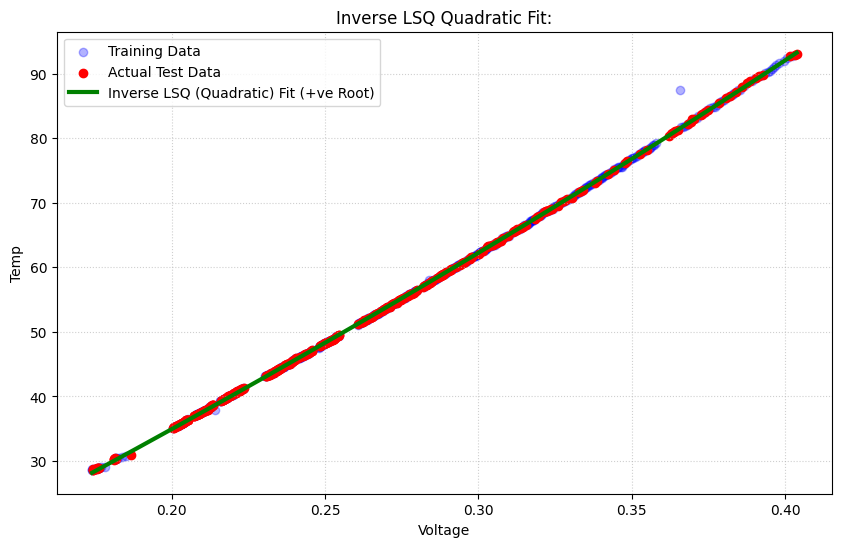

In [42]:
mse_inverse_lsq = mean_squared_error(y_test_valid, y_pred_valid)
r2_inverse_lsq = r2_score(y_test_valid, y_pred_valid)

print(f"\nMean Squared Error (MSE) of Final Y Prediction: {mse_inverse_lsq:f}")
print(f"R-squared (R2) of Final Y Prediction: {r2_inverse_lsq:f}")


plt.figure(figsize=(10, 6))

X_plot = np.linspace(X['X'].min(), X['X'].max(), 500)

y_plot_inverse = inverse_quadratic_predict(X_plot, coeff_a, coeff_b, coeff_c)

plt.scatter(X_train['X'], y_train, color='blue', alpha=0.3, label='Training Data')
plt.scatter(X_test['X'], y_test, color='red', label='Actual Test Data')

plt.plot(X_plot, y_plot_inverse, color='green', linewidth=3, label='Inverse LSQ (Quadratic) Fit (+ve Root)')

plt.title('Inverse LSQ Quadratic Fit:')
plt.xlabel('Voltage')
plt.ylabel('Temp')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [43]:
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

X_train_features = pd.DataFrame({
    'X^2': X_train['X'].values ** 2,
    'X': X_train['X'].values
})

y_train_target = y_train.values

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)

sgd_model = SGDRegressor(
    max_iter=10000,
    tol=1e-6,
    random_state=32,
    learning_rate='adaptive',
    eta0=0.01,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

sgd_model.fit(X_train_scaled, y_train_target)


print("### Stochastic Gradient Descent (Quadratic) Results ###")

scaled_coeffs = sgd_model.coef_
scaled_intercept = sgd_model.intercept_[0]

mu_X2, mu_X = scaler.mean_
sigma_X2, sigma_X = scaler.scale_

coeff_a = scaled_coeffs[0] / sigma_X2
coeff_b = scaled_coeffs[1] / sigma_X
coeff_c = scaled_intercept - (coeff_a * mu_X2) - (coeff_b * mu_X)

print(f"Forward Fit Equation: Y = {coeff_a:.9f}*X^2 + {coeff_b:.9f}*X + {coeff_c:.9f}")

X_test_features = pd.DataFrame({
    'X^2': X_test['X'].values ** 2,
    'X': X_test['X'].values
})

X_test_scaled = scaler.transform(X_test_features)

y_pred_sgd = sgd_model.predict(X_test_scaled)

# print subset of predictions on test data
print(np.column_stack((X_test, y_test, y_pred_sgd))[:10])

### Stochastic Gradient Descent (Quadratic) Results ###
Forward Fit Equation: Y = 190.226107678*X^2 + 173.380527679*X + -7.072446221
[[ 0.2634     51.9        51.79378842]
 [ 0.3127     65.9        65.74419898]
 [ 0.2083     37.2        37.29641736]
 [ 0.4037     93.1        93.92312351]
 [ 0.2092     37.5        37.52393729]
 [ 0.2978     61.6        61.43044685]
 [ 0.2028     35.8        35.91271371]
 [ 0.2666     52.7        52.67122959]
 [ 0.3185     67.5        67.44621622]
 [ 0.285      57.9        57.79211976]]



Mean Squared Error (MSE) of Y Prediction: 0.030477
R-squared (R2) of Y Prediction: 0.999854


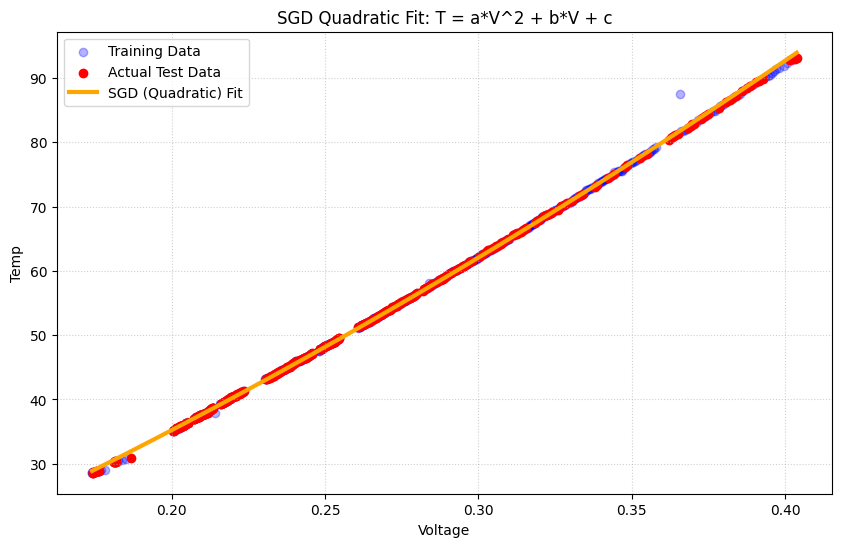

In [44]:
mse_sgd = mean_squared_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

print(f"\nMean Squared Error (MSE) of Y Prediction: {mse_sgd:f}")
print(f"R-squared (R2) of Y Prediction: {r2_sgd:f}")


plt.figure(figsize=(10, 6))

X_plot = np.linspace(X['X'].min(), X['X'].max(), 500)

y_plot_sgd = coeff_a * (X_plot**2) + coeff_b * X_plot + coeff_c

plt.scatter(X_train['X'], y_train, color='blue', alpha=0.3, label='Training Data')
plt.scatter(X_test['X'], y_test, color='red', label='Actual Test Data')

plt.plot(X_plot, y_plot_sgd, color='orange', linewidth=3, label='SGD (Quadratic) Fit')

plt.title('SGD Quadratic Fit: T = a*V^2 + b*V + c')
plt.xlabel('Voltage')
plt.ylabel('Temp')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [45]:
import numpy as np
import pandas as pd

from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

Y_train_inverse_features = pd.DataFrame({
    'Y': y_train.values,
    'Y^2': y_train.values ** 2
})

X_train_target = X_train['X'].values

scaler = StandardScaler()
Y_train_scaled = scaler.fit_transform(Y_train_inverse_features[['Y^2', 'Y']])

inverse_sgd_model = SGDRegressor(
    max_iter=10000,
    tol=1e-6,
    random_state=32,
    learning_rate='adaptive',
    eta0=0.01,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

inverse_sgd_model.fit(Y_train_scaled, X_train_target)


print("### Stochastic Gradient Descent (Quadratic) Results ###")

scaled_coeffs = inverse_sgd_model.coef_
scaled_intercept = inverse_sgd_model.intercept_[0]

mu_Y2, mu_Y = scaler.mean_
sigma_Y2, sigma_Y = scaler.scale_

coeff_a = scaled_coeffs[0] / sigma_Y2
coeff_b = scaled_coeffs[1] / sigma_Y
coeff_c = scaled_intercept - (coeff_a * mu_Y2) - (coeff_b * mu_Y)

print(f"Inverse Fit Equation: X = {coeff_a:.9f}*Y^2 + {coeff_b:.9f}*Y + {coeff_c:.9f}")

def inverse_quadratic_predict(X_vals, a, b, c):
    discriminant = b**2 - 4 * a * (c - X_vals)
    safe_sqrt = np.sqrt(np.maximum(discriminant, 0))
    Y_pred_plus = (-b + safe_sqrt) / (2 * a)
    return np.where(discriminant >= 0, Y_pred_plus, np.nan)


X_test_target = X_test['X'].values
y_pred_inverse_sgd = inverse_quadratic_predict(X_test_target, coeff_a, coeff_b, coeff_c)


valid_indices = ~np.isnan(y_pred_inverse_sgd)
y_test_valid = y_test[valid_indices]
y_pred_valid = y_pred_inverse_sgd[valid_indices]

# print subset of predictions on test data
print(np.column_stack((X_test, y_test, y_pred_valid))[:10])

### Stochastic Gradient Descent (Quadratic) Results ###
Inverse Fit Equation: X = -0.000005386*Y^2 + 0.004183549*Y + 0.060452454
[[ 0.2634     51.9        51.99056017]
 [ 0.3127     65.9        65.88288004]
 [ 0.2083     37.2        37.11340834]
 [ 0.4037     93.1        93.23832702]
 [ 0.2092     37.5        37.35134572]
 [ 0.2978     61.6        61.62190501]
 [ 0.2028     35.8        35.66283394]
 [ 0.2666     52.7        52.87483603]
 [ 0.3185     67.5        67.55681543]
 [ 0.285      57.9        58.00534811]]



Mean Squared Error (MSE) of Final Y Prediction: 0.016221
R-squared (R2) of Final Y Prediction: 0.999922


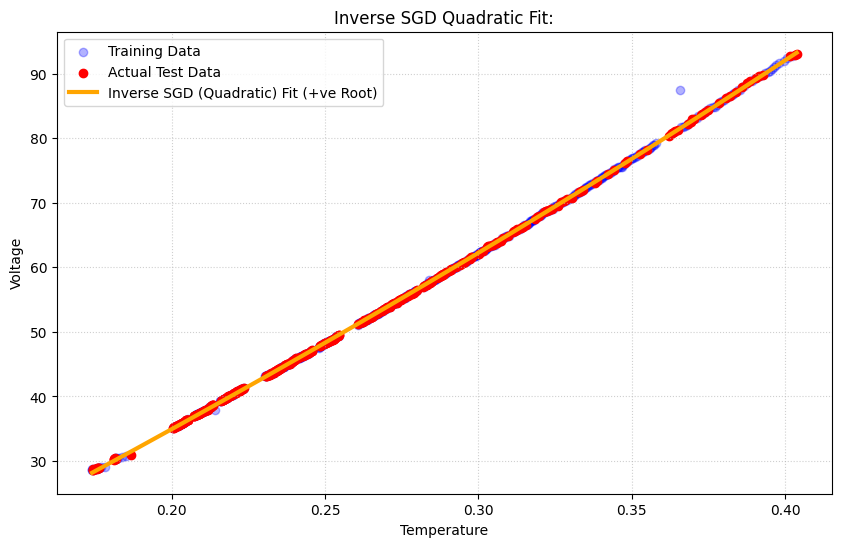

In [46]:
mse_inverse_sgd = mean_squared_error(y_test_valid, y_pred_valid)
r2_inverse_sgd = r2_score(y_test_valid, y_pred_valid)

print(f"\nMean Squared Error (MSE) of Final Y Prediction: {mse_inverse_sgd:f}")
print(f"R-squared (R2) of Final Y Prediction: {r2_inverse_sgd:f}")


plt.figure(figsize=(10, 6))

X_plot = np.linspace(X['X'].min(), X['X'].max(), 500)

y_plot_inversesgd = inverse_quadratic_predict(X_plot, coeff_a, coeff_b, coeff_c)

plt.scatter(X_train['X'], y_train, color='blue', alpha=0.3, label='Training Data')
plt.scatter(X_test['X'], y_test, color='red', label='Actual Test Data')

plt.plot(X_plot, y_plot_inversesgd, color='orange', linewidth=3, label='Inverse SGD (Quadratic) Fit (+ve Root)')

plt.title('Inverse SGD Quadratic Fit:')
plt.xlabel('Voltage')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

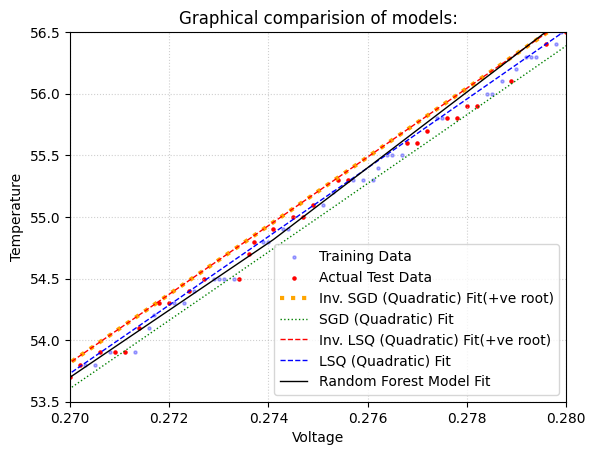

In [76]:
plt.scatter(X_train['X'], y_train, color='blue', alpha=0.3, label='Training Data', s=5)
plt.scatter(X_test['X'], y_test, color='red', label='Actual Test Data', s=5)

plt.plot(X_plot, y_plot_inversesgd, color='orange', linewidth=3, label='Inv. SGD (Quadratic) Fit(+ve root)', linestyle=':')
plt.plot(X_plot, y_plot_sgd, color='green', linewidth=1, label='SGD (Quadratic) Fit', linestyle = ':')
plt.plot(X_plot, y_plot_inverse, color='red', linewidth=1, label='Inv. LSQ (Quadratic) Fit(+ve root)', linestyle='--')
plt.plot(X_plot, y_plot_regular, color='blue', linewidth=1, label='LSQ (Quadratic) Fit', linestyle='--')
plt.plot(X_grid, y_grid_pred, color='black', linewidth=1, label='Random Forest Model Fit')

plt.title('Graphical comparision of models:')
plt.xlabel('Voltage')
plt.ylabel('Temperature')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0.27, 0.28)
plt.ylim(53.5, 56.5)
plt.show()